# INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<h2>Global Tech Workforce Intelligence & Compensation Analysis</h2>
The modern technology job market is undergoing a rapid transformation driven by the expansion of Artificial Intelligence (AI), Machine Learning (ML), and remote work models. Understanding global compensation benchmarks, regional hiring demand, and critical skill combinations is essential for both employers and tech professionals.  This project utilizes the Open Global Workforce Intelligence Platform (OGWIP) dataset—a comprehensive repository combining real-world job posting data from YCombinator's HackerNews, federal public sector feeds (USAJOBS), and LLM-extracted metadata. This project establishes an empirical baseline of global hiring trends through exploratory data analysis and prepares structured feature representations to feed downstream predictive models.

# OJBECTIEVES:

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Primary Objectives (EDA Phase)
<ul>
<li>Compensation & Geographical Mapping: Uncover compensation distributions across key geographic hubs (North America, Europe, APAC) and analyze pay parity across remote, hybrid, and on-site roles.</li>
<li>Tech Stack & Skill Co-occurrence: Quantify market demand for key technical skills (Python, SQL, PyTorch, LLMs, Cloud platforms) and identify high-value skill clusters. </li>
<li> Seniority & Role Benchmark: Evaluate how salary scales across seniority levels (Junior to Staff/Principal) and role classifications (e.g., Data Scientist, DevOps Architect, Product Manager). </li>
</ul>
<li> Future Objectives (ML Phase)Salary Prediction Model (Regression):
<ul> 
<li>Predict continuous compensation figures (salary_in_usd) based on regional features, role category, experience level, and tech stack.</li>
<li>Skill Demand & Seniority Classification (Classification): Build multiclass classifiers to predict job seniority or role tiers using tech stack features and text representation.
<li>Skill Association Mining (NLP / Clustering): Extract latent skill patterns and grouping using topic modeling or unsupervised clustering to track emerging AI tech stacks.
</ul>
</ul>


</div>

<div>

# 1. Getting Ready with Dataset

In [1]:
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pl.read_csv('/home/kartika/Datasets/global_tech_market_2026.csv')
data = data.to_pandas()
data.head()

,job_id,job_title,company_name,location,salary_min_usd,salary_max_usd,tech_stack,source,description,date_posted
0,OGWIP_100001,Product Manager,European Space Agency,"Austin, TX, USA",81405,113143,"Python, SQL, TensorFlow, PyTorch",HackerNews,"We are European Space Agency, looking for a Pr...",2026-08-04 05:00:00
1,OGWIP_100003,NLP Engineer,Federal Bureau of Investigation,Remote - US Only,74906,118550,"Java, Spring Boot, Kafka, PostgreSQL",LinkedIn_Proxy,"We are Federal Bureau of Investigation, lookin...",2026-08-01 13:00:00
2,OGWIP_100004,Lead Data Scientist,AI Solutions LLC,Remote - Global,144270,215864,"Go, Kubernetes, Docker, GCP",LinkedIn_Proxy,"We are AI Solutions LLC, looking for a Lead Da...",2026-08-04 21:00:00
3,OGWIP_100005,Full Stack Developer,NASA,"Seattle, WA, USA",109716,165103,"Python, Airflow, Snowflake, dbt",HackerNews,"We are NASA, looking for a Full Stack Develope...",2026-08-02 22:00:00
4,OGWIP_100006,Technical Program Manager,Quantum Data,"Amsterdam, Netherlands",73276,111586,"JavaScript, React, Node.js, MongoDB",HackerNews,"We are Quantum Data, looking for a Technical P...",2026-08-02 05:00:00


In [3]:
data.tail()

,job_id,job_title,company_name,location,salary_min_usd,salary_max_usd,tech_stack,source,description,date_posted
11998,OGWIP_114995,Analytics Engineer,AI Solutions LLC,"Berlin, Germany",66203,89794,"Ruby on Rails, Redis, Heroku",HackerNews,"We are AI Solutions LLC, looking for a Analyti...",2026-08-01 07:00:00
11999,OGWIP_114996,Cybersecurity Analyst,GlobalSystems Inc,"Seattle, WA, USA",122405,148161,"Rust, WebAssembly, System Architecture",Glassdoor_Scrape,"We are GlobalSystems Inc, looking for a Cybers...",2026-08-03 16:00:00
12000,OGWIP_114997,Senior Data Scientist,TechNova,"Amsterdam, Netherlands",124022,192159,"Go, Kubernetes, Docker, GCP",Glassdoor_Scrape,"We are TechNova, looking for a Senior Data Sci...",2026-08-01 11:00:00
12001,OGWIP_114998,Analytics Engineer,Globex,"New York, NY, USA",106839,179666,"C++, CUDA, Computer Vision",HackerNews,"We are Globex, looking for a Analytics Enginee...",2026-08-02 14:00:00
12002,OGWIP_114999,Technical Program Manager,FinTech Innovations,"Austin, TX, USA",84827,119438,"Go, Kubernetes, Docker, GCP",LinkedIn_Proxy,"We are FinTech Innovations, looking for a Tech...",2026-08-01 10:00:00


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12003 entries, 0 to 12002
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_id          12003 non-null  object
 1   job_title       12003 non-null  object
 2   company_name    12003 non-null  object
 3   location        12003 non-null  object
 4   salary_min_usd  12003 non-null  int64 
 5   salary_max_usd  12003 non-null  int64 
 6   tech_stack      12003 non-null  object
 7   source          12003 non-null  object
 8   description     12003 non-null  object
 9   date_posted     12003 non-null  object
dtypes: int64(2), object(8)
memory usage: 937.9+ KB


In [5]:
print(f"Size: {data.size}\n Shape: {data.shape}")

Size: 120030
 Shape: (12003, 10)


<div>

# 2. Cleaning and Wraggling

In [6]:
data.isnull().sum()

job_id            0
job_title         0
company_name      0
location          0
salary_min_usd    0
salary_max_usd    0
tech_stack        0
source            0
description       0
date_posted       0
dtype: int64

In [7]:
data.duplicated().sum()

np.int64(0)

## 2.1 Categorical Fields

In [8]:
data['job_title'].map(type).unique()
data['company_name'].map(type).unique()
data['location'].map(type).unique()
data['source'].map(type).unique()
data['description'].map(type).unique()

array([<class 'str'>], dtype=object)

In [9]:
data['job_title'] = data['job_title'].astype('string[pyarrow]')
data['company_name'] = data['company_name'].astype('string[pyarrow]')
data['location'] = data['location'].astype('string[pyarrow]')
data['source'] = data['source'].astype('string[pyarrow]')
data['description'] = data['description'].astype('string[pyarrow]')

In [10]:
data['tech_stack']

0              Python, SQL, TensorFlow, PyTorch
1          Java, Spring Boot, Kafka, PostgreSQL
2                   Go, Kubernetes, Docker, GCP
3               Python, Airflow, Snowflake, dbt
4           JavaScript, React, Node.js, MongoDB
                          ...                  
11998              Ruby on Rails, Redis, Heroku
11999    Rust, WebAssembly, System Architecture
12000               Go, Kubernetes, Docker, GCP
12001                C++, CUDA, Computer Vision
12002               Go, Kubernetes, Docker, GCP
Name: tech_stack, Length: 12003, dtype: object

In [27]:
# data['tech_stack'] = data['tech_stack'].astype('str[pyarrow]')
data['tech_skills'] = data['tech_stack'].str.split(',')
df = data.explode('tech_skills').reset_index(drop = True)
df['tech_skills'] = df['tech_skills'].str.strip()
df['tech_skills']

0                 Python
1                    SQL
2             TensorFlow
3                PyTorch
4                   Java
              ...       
43170    Computer Vision
43171                 Go
43172         Kubernetes
43173             Docker
43174                GCP
Name: tech_skills, Length: 43175, dtype: object

In [12]:
data['date_posted']

0        2026-08-04 05:00:00
1        2026-08-01 13:00:00
2        2026-08-04 21:00:00
3        2026-08-02 22:00:00
4        2026-08-02 05:00:00
                ...         
11998    2026-08-01 07:00:00
11999    2026-08-03 16:00:00
12000    2026-08-01 11:00:00
12001    2026-08-02 14:00:00
12002    2026-08-01 10:00:00
Name: date_posted, Length: 12003, dtype: object

In [13]:
data['date_posted'] = pd.to_datetime(data['date_posted'])
data['posted_month'] = data['date_posted'].dt.strftime('%m')
data['posted_month']

0        08
1        08
2        08
3        08
4        08
         ..
11998    08
11999    08
12000    08
12001    08
12002    08
Name: posted_month, Length: 12003, dtype: object

## 2.2 Numerical Fields

In [14]:
data['salary_min_usd']

0         81405
1         74906
2        144270
3        109716
4         73276
          ...  
11998     66203
11999    122405
12000    124022
12001    106839
12002     84827
Name: salary_min_usd, Length: 12003, dtype: int64

In [15]:
data['salary_max_usd']

0        113143
1        118550
2        215864
3        165103
4        111586
          ...  
11998     89794
11999    148161
12000    192159
12001    179666
12002    119438
Name: salary_max_usd, Length: 12003, dtype: int64

<div>

<div
>

#  Descriptive EDA

# 3. Univariate Analysis

## 3.1 Categorical Fields

In [16]:
data['job_title'].value_counts()

job_title
Backend Developer            635
DevOps Engineer              627
Frontend Developer           625
Site Reliability Engineer    622
Lead Data Scientist          620
Data Scientist               618
Analytics Engineer           606
Full Stack Developer         604
NLP Engineer                 601
Technical Program Manager    595
Cloud Architect              595
Data Engineer                594
Senior Software Engineer     593
Software Engineer            592
Staff Engineer               591
Product Manager              588
Cybersecurity Analyst        578
Senior Data Scientist        577
Machine Learning Engineer    575
AI Researcher                567
Name: count, dtype: int64[pyarrow]

In [17]:
job_mapper = {
    "Backend Developer": "Software Engineering",
    "Frontend Developer": "Software Engineering",
    "Full Stack Developer": "Software Engineering",
    "Senior Software Engineer": "Software Engineering",
    "Software Engineer": "Software Engineering",
    "Staff Engineer": "Software Engineering",
    "Lead Data Scientist": "Data & AI",
    "Data Scientist": "Data & AI",
    "Analytics Engineer": "Data & AI",
    "NLP Engineer": "Data & AI",
    "Data Engineer": "Data & AI",
    "Senior Data Scientist": "Data & AI",
    "Machine Learning Engineer": "Data & AI",
    "AI Researcher": "Data & AI",
    "DevOps Engineer": "Cloud & Security",
    "Site Reliability Engineer": "Cloud & Security",
    "Cloud Architect": "Cloud & Security",
    "Cybersecurity Analyst": "Cloud & Security",
    "Technical Program Manager": "Product & Management",
    "Product Manager": "Product & Management",
}
data['job_category'] = data['job_title'].map(job_mapper)

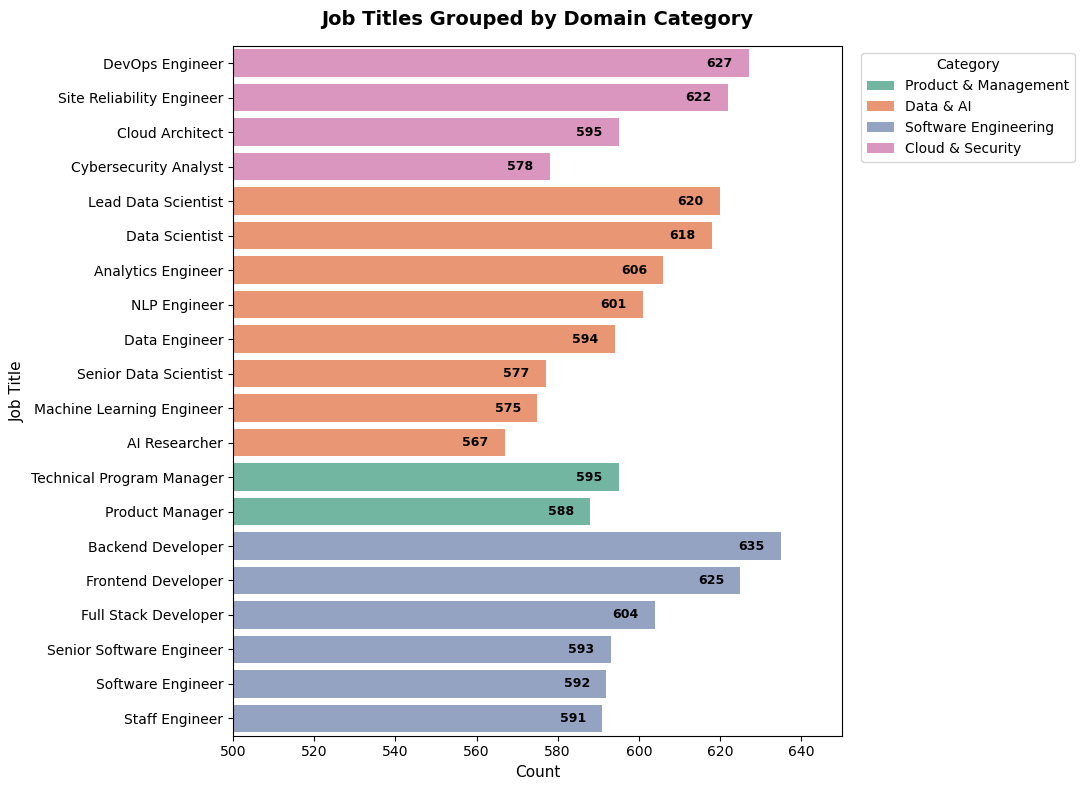

In [18]:
job_order = (
    data.groupby(["job_category", "job_title"])
    .size()
    .reset_index(name="count")
    .sort_values(by=["job_category", "count"], ascending=[True, False])[
        "job_title"
    ]
    .tolist()
)


plt.figure(figsize=(11, 8))
ax = sns.countplot(
    data=data,
    y="job_title",
    hue="job_category",
    order=job_order,
    dodge=False,
    palette="Set2",
)


for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{int(width)}",
            (width - 4, p.get_y() + p.get_height() / 2.0),
            ha="right",
            va="center",
            color="black",
            fontsize=9,
            fontweight="bold",
        )


plt.title(
    "Job Titles Grouped by Domain Category",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Count", fontsize=11)
plt.ylabel("Job Title", fontsize=11)
plt.xlim(500, 650)
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">By number of job listings, DevOps Engineer is at top in cloud & security, Lead Data Scientis in Data & AI, Technical Program Manager in Product & Management and Backend Developer in Software Engineering job categories.

<div>

In [19]:
data['company_name'].value_counts()

company_name
NASA                               736
CyberDyne                          734
EduTech Global                     732
Initech                            729
GlobalSystems Inc                  720
Wayne Enterprises                  713
European Space Agency              710
HealthAI                           710
Department of Defense              704
Umbrella Corp                      700
Quantum Data                       698
AI Solutions LLC                   694
FinTech Innovations                690
Globex                             690
Federal Bureau of Investigation    687
Stark Industries                   678
TechNova                           678
Name: count, dtype: int64[pyarrow]

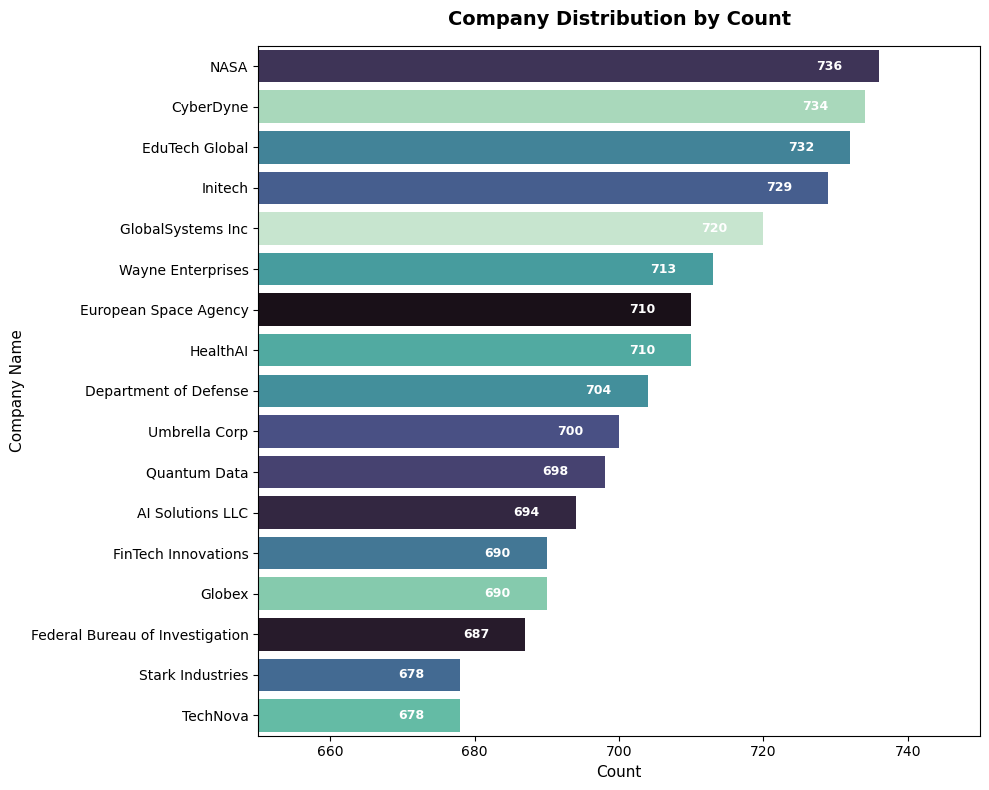

In [20]:

company_order = (
    data["company_name"].value_counts().index.tolist()
)  


plt.figure(figsize=(10, 8))
ax = sns.countplot(
    data=data,
    y="company_name",
    order=company_order,  
    palette="mako",
    hue="company_name",
)


for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{int(width)}",
            (width - 5, p.get_y() + p.get_height() / 2.0),
            ha="right",
            va="center",
            color="white",
            fontsize=9,
            fontweight="bold",
        )

plt.title(
    "Company Distribution by Count", fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Count", fontsize=11)
plt.ylabel("Company Name", fontsize=11)
plt.xlim(650, 750)
plt.tight_layout()

plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">NASA, CyberDyne and Edu Tech Global are top three companies by most number of jobs featured in the dataset.

<div>

In [21]:
data['location'].value_counts()

location
Remote - APAC             822
Bengaluru, India          795
Seattle, WA, USA          789
Toronto, Canada           774
San Francisco, CA, USA    770
Austin, TX, USA           767
Remote - US Only          756
Singapore                 752
Amsterdam, Netherlands    744
Berlin, Germany           743
Paris, France             735
London, UK                733
Remote - Global           713
New York, NY, USA         710
Sydney, Australia         704
Remote - EMEA             696
Name: count, dtype: int64[pyarrow]

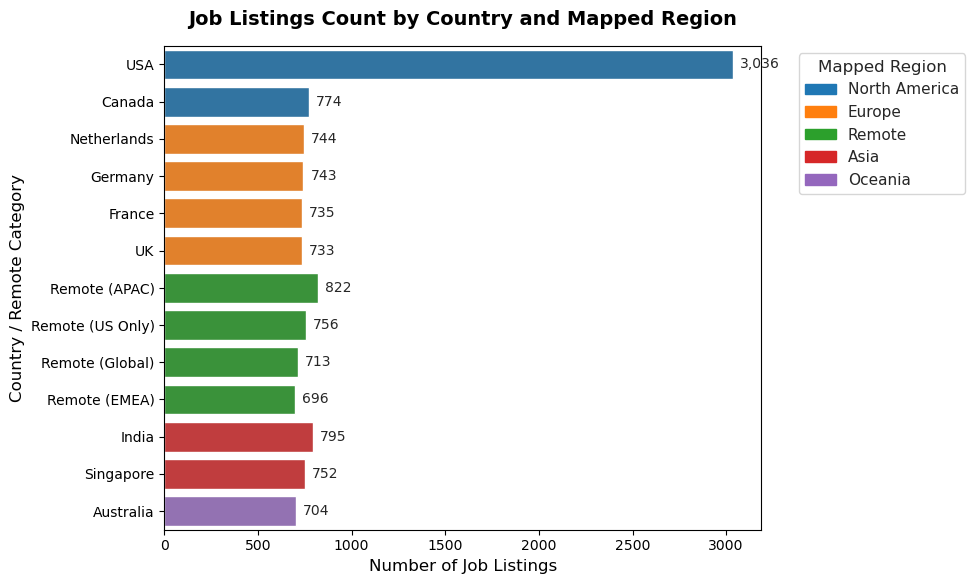

In [22]:

values = {
    "Remote - APAC": 822,
    "Bengaluru, India": 795,
    "Seattle, WA, USA": 789,
    "Toronto, Canada": 774,
    "San Francisco, CA, USA": 770,
    "Austin, TX, USA": 767,
    "Remote - US Only": 756,
    "Singapore": 752,
    "Amsterdam, Netherlands": 744,
    "Berlin, Germany": 743,
    "Paris, France": 735,
    "London, UK": 733,
    "Remote - Global": 713,
    "New York, NY, USA": 710,
    "Sydney, Australia": 704,
    "Remote - EMEA": 696,
}

location_to_country = {
    "Bengaluru, India": "India",
    "Seattle, WA, USA": "USA",
    "Toronto, Canada": "Canada",
    "San Francisco, CA, USA": "USA",
    "Austin, TX, USA": "USA",
    "Singapore": "Singapore",
    "Amsterdam, Netherlands": "Netherlands",
    "Berlin, Germany": "Germany",
    "Paris, France": "France",
    "London, UK": "UK",
    "New York, NY, USA": "USA",
    "Sydney, Australia": "Australia",
    "Remote - APAC": "Remote (APAC)",
    "Remote - US Only": "Remote (US Only)",
    "Remote - Global": "Remote (Global)",
    "Remote - EMEA": "Remote (EMEA)",
}

country_to_region = {
    "USA": "North America",
    "Canada": "North America",
    "India": "Asia",
    "Singapore": "Asia",
    "Netherlands": "Europe",
    "Germany": "Europe",
    "France": "Europe",
    "UK": "Europe",
    "Australia": "Oceania",
    "Remote (APAC)": "Remote",
    "Remote (US Only)": "Remote",
    "Remote (Global)": "Remote",
    "Remote (EMEA)": "Remote",
}


df = pd.DataFrame(list(values.items()), columns=["Location", "Count"])
df["Country"] = df["Location"].map(location_to_country)
df["Region"] = df["Country"].map(country_to_region)


df["Region"] = df["Region"].astype(str)
df["Country"] = df["Country"].astype(str)

region_order = ["North America", "Europe", "Remote", "Asia", "Oceania"]

grouped = (
    df.groupby(["Region", "Country"], observed=True)["Count"]
    .sum()
    .reset_index()
)


grouped["Region_Cat"] = pd.Categorical(
    grouped["Region"], categories=region_order, ordered=True
)
grouped = grouped.sort_values(
    by=["Region_Cat", "Count"], ascending=[True, False]
)


fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

palette = {
    "North America": "#1f77b4",
    "Europe": "#ff7f0e",
    "Remote": "#2ca02c",
    "Asia": "#d62728",
    "Oceania": "#9467bd",
}


sns.barplot(
    data=grouped,
    x="Count",
    y="Country",
    hue="Region",
    hue_order=region_order,
    palette=palette,
    dodge=False,
    ax=ax,
)


legend_handles = [
    mpatches.Patch(color=color, label=region)
    for region, color in palette.items()
]

ax.legend(
    handles=legend_handles,
    title="Mapped Region",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

ax.set_title(
    "Job Listings Count by Country and Mapped Region",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Number of Job Listings", fontsize=12)
ax.set_ylabel("Country / Remote Category", fontsize=12)


for p in ax.patches:
  width = p.get_width()
  if width > 0:
    ax.annotate(
        f"{int(width):,}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">USA has highest number of job listings. Number of remote job listings are also very high.

<div>

In [23]:
data['tech_stack'].value_counts()

tech_stack
Java, Spring Boot, Kafka, PostgreSQL      1255
Ruby on Rails, Redis, Heroku              1241
Rust, WebAssembly, System Architecture    1241
Python, SQL, TensorFlow, PyTorch          1205
TypeScript, Angular, Firebase             1189
Python, Airflow, Snowflake, dbt           1186
Go, Kubernetes, Docker, GCP               1184
Python, Pandas, Scikit-Learn, AWS         1176
C++, CUDA, Computer Vision                1166
JavaScript, React, Node.js, MongoDB       1160
Name: count, dtype: int64

In [28]:
df['tech_skills'].value_counts()

tech_skills
Python                 3567
Spring Boot            1255
PostgreSQL             1255
Java                   1255
Kafka                  1255
WebAssembly            1241
Heroku                 1241
System Architecture    1241
Ruby on Rails          1241
Rust                   1241
Redis                  1241
SQL                    1205
TensorFlow             1205
PyTorch                1205
TypeScript             1189
Firebase               1189
Angular                1189
Airflow                1186
Snowflake              1186
dbt                    1186
Go                     1184
Kubernetes             1184
GCP                    1184
Docker                 1184
Scikit-Learn           1176
Pandas                 1176
AWS                    1176
C++                    1166
CUDA                   1166
Computer Vision        1166
Node.js                1160
React                  1160
JavaScript             1160
MongoDB                1160
Name: count, dtype: int64

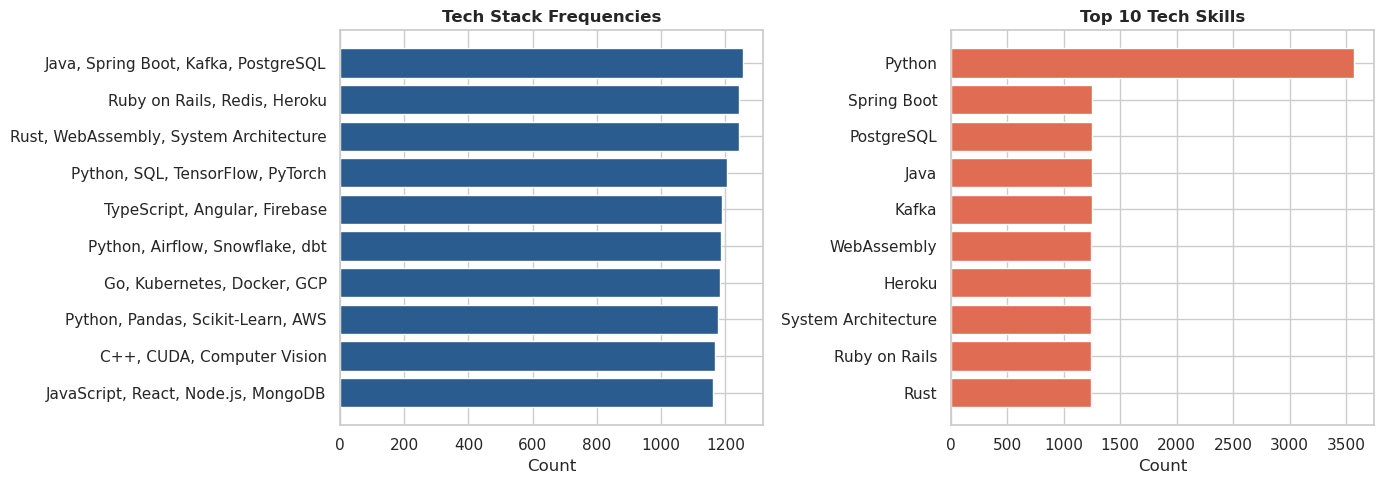

In [ ]:
stack_counts = data["tech_stack"].value_counts()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.barh(stack_counts.index[::-1], stack_counts.values[::-1], color="#2b5c8f")
ax1.set_title("Tech Stack Frequencies", fontsize=12, fontweight="bold")
ax1.set_xlabel("Count")


ax2.barh(
    y = df['tech_skills'].value_counts().nlargest(10).index,
    width = df['tech_skills'].value_counts().nlargest(10).values,
    color="#e06d53")
ax2.set_title("Top 10 Tech Skills", fontsize=12, fontweight="bold")
ax2.set_xlabel("Count")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Java, Spring Boot, Kafka, PostgreSQL is most frequent tech stack and Python is most frequent tech skill.

<div>

In [ ]:
data['source'].value_counts()

source
HackerNews             11093
Glassdoor_Scrape       10991
Company_Career_Page    10667
LinkedIn_Proxy         10424
Name: count, dtype: int64[pyarrow]

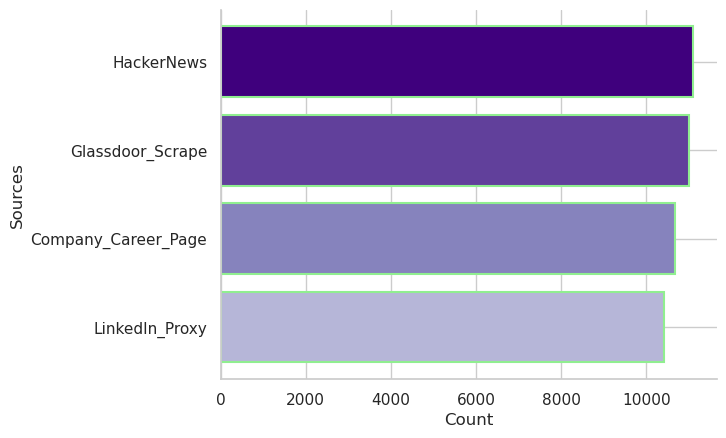

In [ ]:
plt.barh(
    y = data['source'].value_counts().index,
    width = data['source'].value_counts().values,
    color = plt.cm.Purples(np.linspace(1, 0.4, 4)),
    linewidth = 1.5,
    edgecolor = 'lightgreen',

)

plt.ylabel('Sources')
plt.xlabel('Count')
plt.gca().invert_yaxis()
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">HackerNews is the major source of the job listings featured in the dataset.

<div>

## 3.2 Datetime Fields

In [ ]:
data['posted_month'].value_counts()

posted_month
08    12003
Name: count, dtype: int64

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">All postings are from August, 2026.

## 3.2 Numerical Fields

In [ ]:
data['salary_max_usd'].describe()

count     12003.000000
mean     141565.404316
std       49137.782038
min       42002.000000
25%      108922.500000
50%      131587.000000
75%      170455.500000
max      326671.000000
Name: salary_max_usd, dtype: float64

In [ ]:
data['salary_min_usd'].describe()

count     12003.000000
mean     100923.489794
std       34277.942625
min       32013.000000
25%       79094.000000
50%       92003.000000
75%      120280.500000
max      221927.000000
Name: salary_min_usd, dtype: float64

In [ ]:
data['salary_min_usd'].skew()

np.float64(0.7574958831464147)

In [ ]:
data['salary_max_usd'].skew()

np.float64(0.7920929330406586)

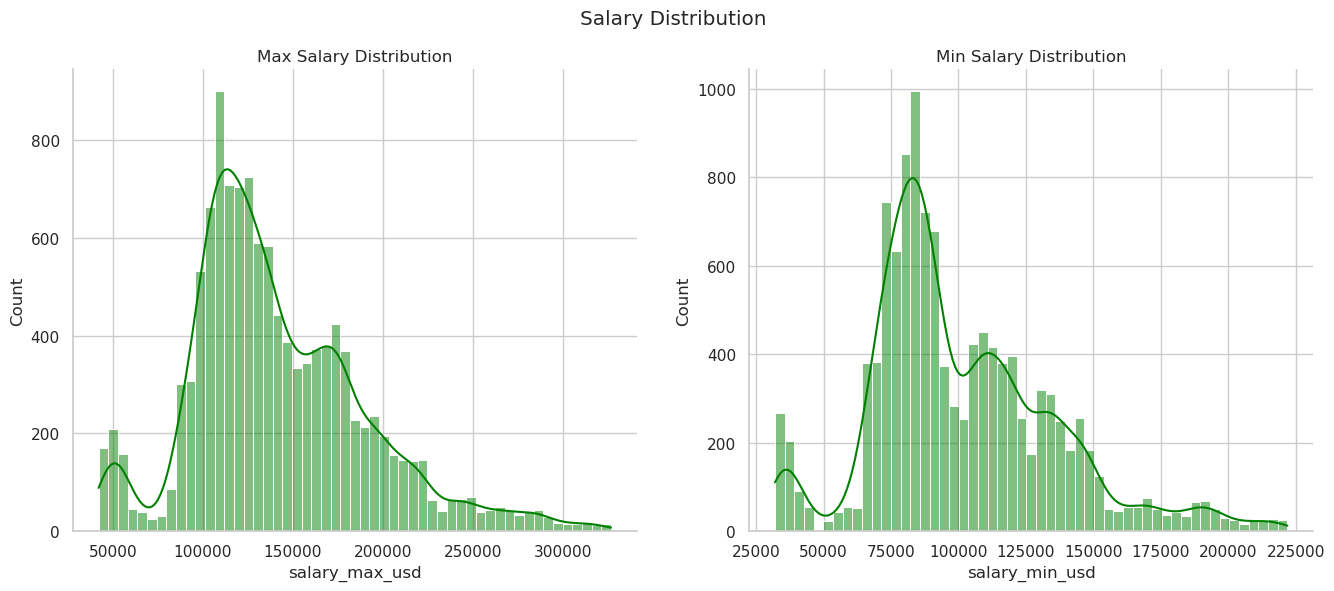

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (16,6))

sns.histplot(
    data = data,
    x = 'salary_max_usd',
    color = 'green',
    kde = True,
    ax = ax[0]
)
ax[0].set_title('Max Salary Distribution')



sns.histplot(
    data = data,
    x = 'salary_min_usd',
    color = 'green',
    kde = True,
    ax = ax[1]
)
ax[1].set_title('Min Salary Distribution')


plt.suptitle('Salary Distribution')
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Both max and min salary distribution is moderately positively skewed. 

<div>

# 4. Bivarite Analysis

## 4.1 Numerical vs Numerical


In [29]:
data.loc[data['salary_min_usd'] > data['salary_max_usd']]

,job_id,job_title,company_name,location,salary_min_usd,salary_max_usd,tech_stack,source,description,date_posted,tech_skills,posted_month,job_category


In [30]:
data['salary_min_usd'].corr(data['salary_max_usd'])

np.float64(0.9568704029767298)

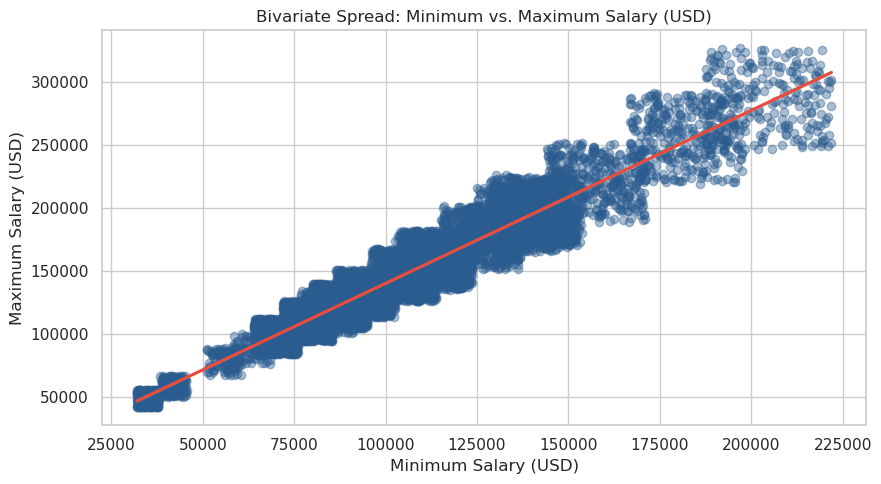

In [ ]:


plt.figure(figsize=(9, 5))
sns.regplot(
    data=data,
    x='salary_min_usd',
    y='salary_max_usd',
    scatter_kws={'alpha': 0.4, 'color': '#2b5c8f'},
    line_kws={'color': '#e74c3c'}
)
plt.title('Bivariate Spread: Minimum vs. Maximum Salary (USD)')
plt.xlabel('Minimum Salary (USD)')
plt.ylabel('Maximum Salary (USD)')
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There is high positive linear correlation between salary range.

<div>

## 4.2 Numerical vs Categorical

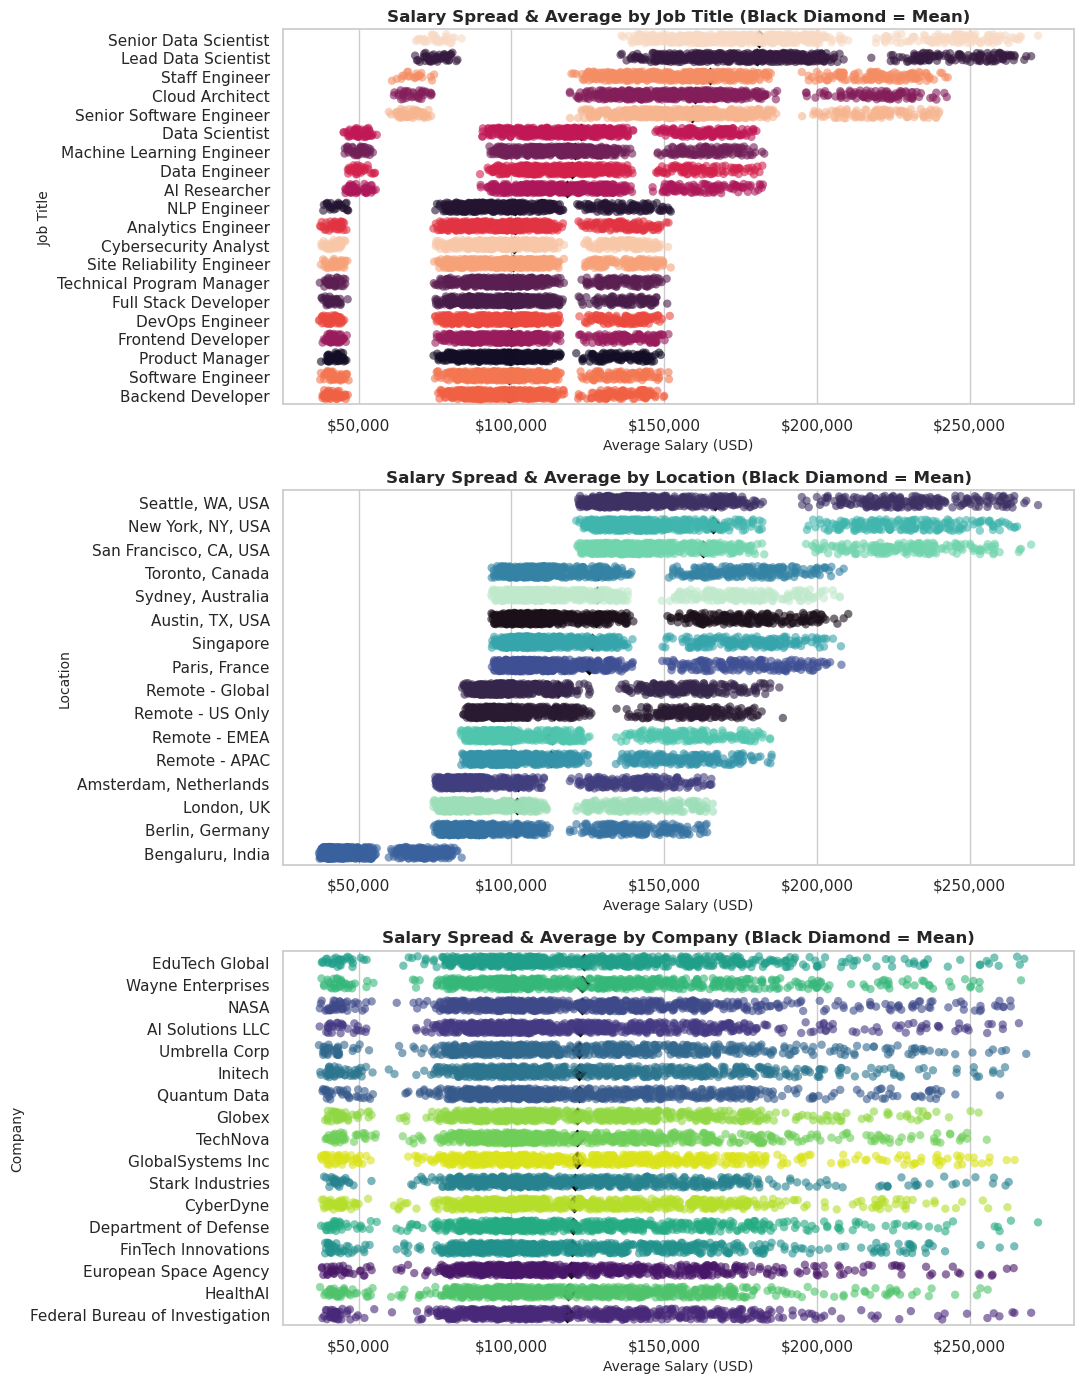

In [ ]:
data["avg_salary_usd"] = (data["salary_min_usd"] + data["salary_max_usd"]) / 2


categories = [
    ("job_title", "Job Title", "rocket"),
    ("location", "Location", "mako"),
    ("company_name", "Company", "viridis"),
]

fig, axes = plt.subplots(len(categories), 1, figsize=(11, 14))
sns.set_theme(style="whitegrid")

for idx, (col, title_label, palette) in enumerate(categories):
    ax = axes[idx]

    
    order = (
        data.groupby(col)["avg_salary_usd"]
        .mean()
        .sort_values(ascending=False)
        .index
    )


    sns.stripplot(
        data=data,
        x="avg_salary_usd",
        y=col,
        hue=col,
        jitter=0.25,
        size=6,
        alpha=0.6,
        palette=palette,
        ax=ax,
        order=order,
        legend=False,
    )

    
    sns.pointplot(
        data=data,
        x="avg_salary_usd",
        y=col,
        estimator=np.mean,
        color="black",
        markers="D",
        linestyles="",
        errorbar=None,
        ax=ax,
        order=order,
    )

    
    ax.set_title(
        f"Salary Spread & Average by {title_label} (Black Diamond = Mean)",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Average Salary (USD)", fontsize=10)
    ax.set_ylabel(title_label, fontsize=10)
    ax.xaxis.set_major_formatter("${x:,.0f}")

plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Senior DataScientist, Lead DataScientist and Staff Engineer have high average salary.<br>
Location wise, Seattle, New York and San Francisco cities from USA have high average salary.
<br>
All the companies in the dataset have all range of salary.

<div>

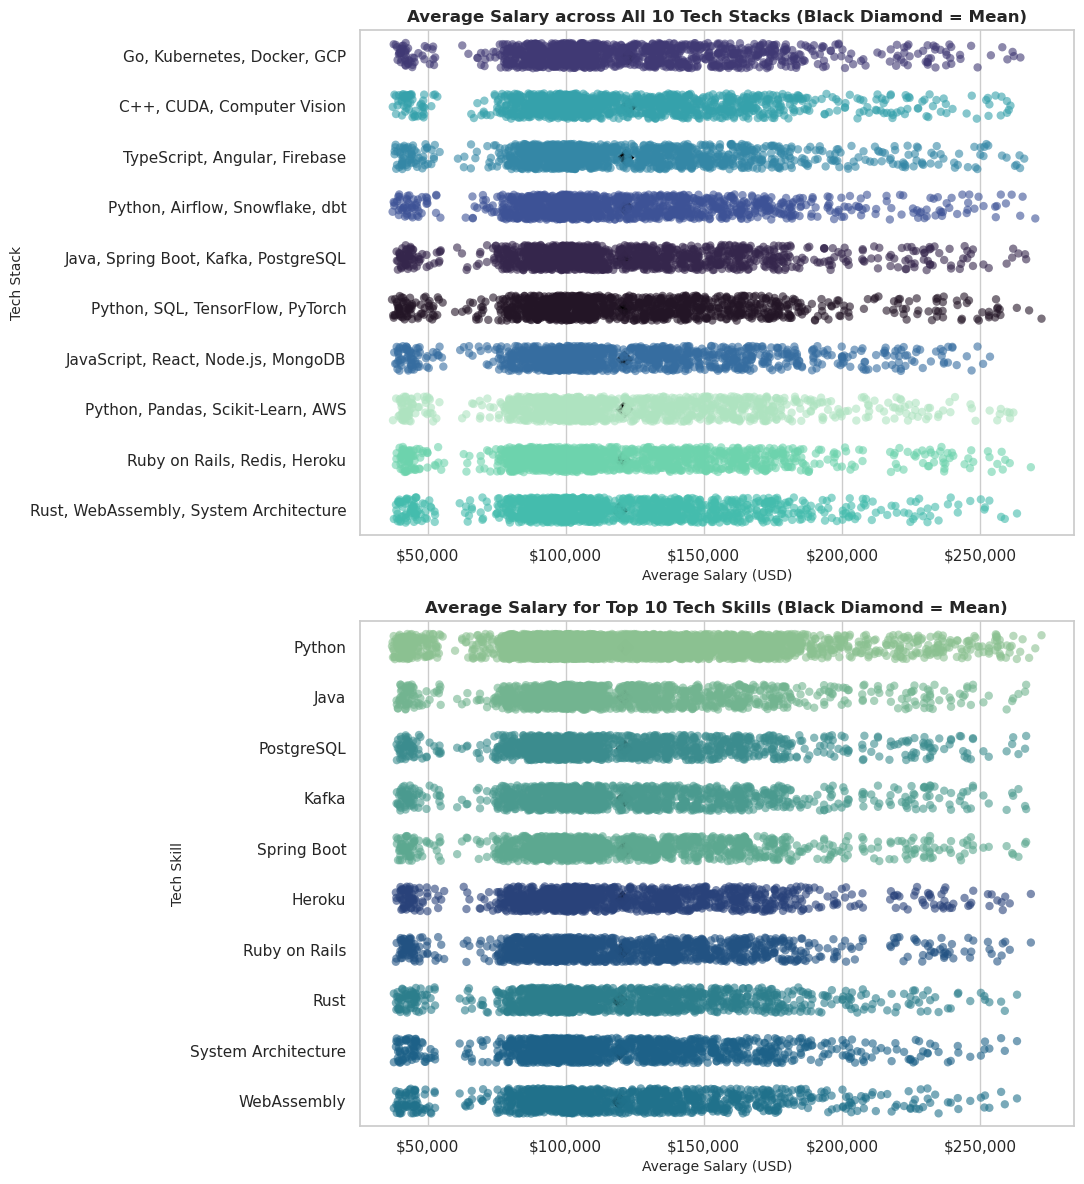

In [ ]:
stack_order = (
    data.groupby("tech_stack")["avg_salary_usd"]
    .mean()
    .sort_values(ascending=False)
    .index
)


top_10_skill_names = df["tech_skills"].value_counts().nlargest(10).index
df_skills_top10 = df[df["tech_skills"].isin(top_10_skill_names)]

skills_order = (
    df_skills_top10.groupby("tech_skills")["avg_salary_usd"]
    .mean()
    .sort_values(ascending=False)
    .index
)


fig, axes = plt.subplots(2, 1, figsize=(11, 12))
sns.set_theme(style="whitegrid")


sns.stripplot(
    data=data,
    x="avg_salary_usd",
    y="tech_stack",
    hue="tech_stack",
    jitter=0.25,
    size=6,
    alpha=0.6,
    palette="mako",
    order=stack_order,
    ax=axes[0],
    legend=False,
)
sns.pointplot(
    data=data,
    x="avg_salary_usd",
    y="tech_stack",
    estimator=np.mean,
    color="black",
    markers="D",
    linestyles="",
    errorbar=None,
    order=stack_order,
    ax=axes[0],
)
axes[0].set_title(
    "Average Salary across All 10 Tech Stacks (Black Diamond = Mean)",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Average Salary (USD)", fontsize=10)
axes[0].set_ylabel("Tech Stack", fontsize=10)
axes[0].xaxis.set_major_formatter("${x:,.0f}")


sns.stripplot(
    data=df_skills_top10,
    x="avg_salary_usd",
    y="tech_skills",
    hue="tech_skills",
    jitter=0.25,
    size=6,
    alpha=0.6,
    palette="crest",
    order=skills_order,
    ax=axes[1],
    legend=False,
)
sns.pointplot(
    data=df_skills_top10,
    x="avg_salary_usd",
    y="tech_skills",
    estimator=np.mean,
    color="black",
    markers="D",
    linestyles="",
    errorbar=None,
    order=skills_order,
    ax=axes[1],
)
axes[1].set_title(
    "Average Salary for Top 10 Tech Skills (Black Diamond = Mean)",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Average Salary (USD)", fontsize=10)
axes[1].set_ylabel("Tech Skill", fontsize=10)
axes[1].xaxis.set_major_formatter("${x:,.0f}")

plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">For all the tech stacks and top 10 tech skills, most of the observations are concentrated around salary range $100K-$175K.

<divv>

<div>

# ML Oriented EDA

## 5. Target Variable Engineering 

In [31]:
data['avg_salary_usd'] = (data['salary_max_usd'] + data['salary_min_usd'])/2
data['salary_range_usd'] = data['salary_max_usd'] - data['salary_min_usd']

In [32]:
data['avg_salary_usd'].skew()

np.float64(0.7617846574406268)

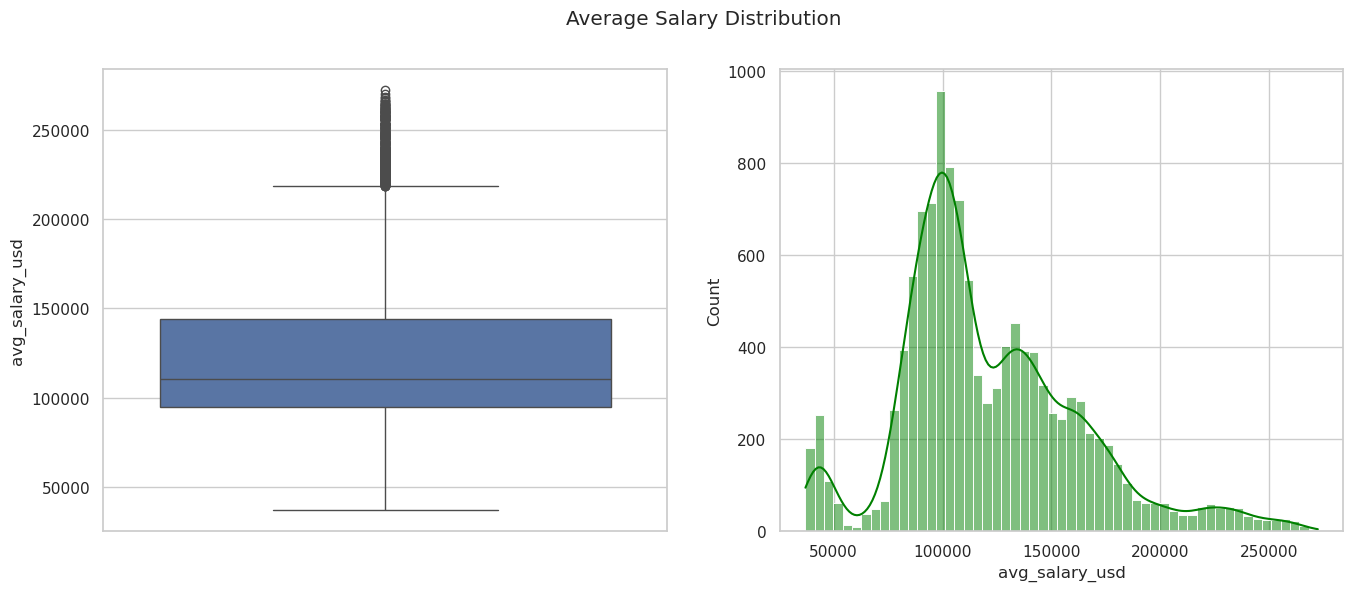

In [33]:
fig, ax = plt.subplots(1, 2, figsize = (16,6))

sns.boxplot(
    y = data['avg_salary_usd'],
    ax = ax[0]
)

sns.histplot(
    data = data,
    x = 'avg_salary_usd',
    color = 'green',
    kde = True
)

plt.suptitle('Average Salary Distribution')
plt.show()

In [34]:
Q1 = data['avg_salary_usd'].quantile(0.25)
Q3 = data['avg_salary_usd'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['avg_salary_usd'] < lower) | (data['avg_salary_usd'] > upper)]
outliers

,job_id,job_title,company_name,location,salary_min_usd,salary_max_usd,tech_stack,source,description,date_posted,tech_skills,posted_month,job_category,avg_salary_usd,salary_range_usd
19,OGWIP_100023,Lead Data Scientist,Wayne Enterprises,"New York, NY, USA",217373,251503,"Python, SQL, TensorFlow, PyTorch",HackerNews,"We are Wayne Enterprises, looking for a Lead D...",2026-08-02 06:00:00,"[Python, SQL, TensorFlow, PyTorch]",08,Data & AI,234438.0,34130
92,OGWIP_100107,Senior Software Engineer,NASA,"Seattle, WA, USA",186919,257900,"Python, SQL, TensorFlow, PyTorch",Company_Career_Page,"We are NASA, looking for a Senior Software Eng...",2026-08-03 04:00:00,"[Python, SQL, TensorFlow, PyTorch]",08,Software Engineering,222409.5,70981
156,OGWIP_100182,Senior Software Engineer,NASA,"Seattle, WA, USA",188980,266197,"TypeScript, Angular, Firebase",LinkedIn_Proxy,"We are NASA, looking for a Senior Software Eng...",2026-08-04 05:00:00,"[TypeScript, Angular, Firebase]",08,Software Engineering,227588.5,77217
180,OGWIP_100210,Senior Software Engineer,Quantum Data,"Seattle, WA, USA",175962,262270,"TypeScript, Angular, Firebase",LinkedIn_Proxy,"We are Quantum Data, looking for a Senior Soft...",2026-08-03 06:00:00,"[TypeScript, Angular, Firebase]",08,Software Engineering,219116.0,86308
263,OGWIP_100307,Senior Data Scientist,Initech,"San Francisco, CA, USA",216871,298517,"Rust, WebAssembly, System Architecture",HackerNews,"We are Initech, looking for a Senior Data Scie...",2026-08-02 18:00:00,"[Rust, WebAssembly, System Architecture]",08,Data & AI,257694.0,81646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11894,OGWIP_114861,Senior Software Engineer,European Space Agency,"San Francisco, CA, USA",191636,283728,"C++, CUDA, Computer Vision",HackerNews,"We are European Space Agency, looking for a Se...",2026-08-04 11:00:00,"[C++, CUDA, Computer Vision]",08,Software Engineering,237682.0,92092
11898,OGWIP_114865,Cloud Architect,GlobalSystems Inc,"Seattle, WA, USA",173894,288571,"Ruby on Rails, Redis, Heroku",Company_Career_Page,"We are GlobalSystems Inc, looking for a Cloud ...",2026-08-03 19:00:00,"[Ruby on Rails, Redis, Heroku]",08,Cloud & Security,231232.5,114677
11916,OGWIP_114891,Staff Engineer,NASA,"San Francisco, CA, USA",172107,276215,"TypeScript, Angular, Firebase",LinkedIn_Proxy,"We are NASA, looking for a Staff Engineer base...",2026-08-02 15:00:00,"[TypeScript, Angular, Firebase]",08,Software Engineering,224161.0,104108
11921,OGWIP_114898,Staff Engineer,TechNova,"Seattle, WA, USA",184958,257878,"C++, CUDA, Computer Vision",Glassdoor_Scrape,"We are TechNova, looking for a Staff Engineer ...",2026-08-04 15:00:00,"[C++, CUDA, Computer Vision]",08,Software Engineering,221418.0,72920


In [35]:
len(outliers), len(outliers)/len(data)*100

(413, 3.440806465050404)

In [ ]:
data['avg_salary_usd'].corr(data['salary_range_usd'])

np.float64(0.784862416602782)

In [36]:
df = data.loc[:, ['avg_salary_usd']]
df['avg_salary_usd'] = np.log1p(df['avg_salary_usd'])
print(f"Skewness before log transformation: {data['avg_salary_usd'].skew()}")
print(f"Skewness after log transformation: {df['avg_salary_usd'].skew()}")

Skewness before log transformation: 0.7617846574406268
Skewness after log transformation: -0.5330780355933008


In [39]:
data = data.drop(columns=["posted_month"])  # Same month (August)


data["day_of_week"] = data["date_posted"].dt.dayofweek
data["day_of_month"] = data["date_posted"].dt.day